In [1]:
#Cell 1 — load model, load and prepare CICDDoS2019:
import sys, os, json
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import joblib

from src.utils import load_config, set_seed
from src.evaluation.metrics import evaluate_model, print_metrics
from src.preprocessing.cross_dataset_cleaning import clean_target_dataset

cfg = load_config()
set_seed(cfg["project"]["random_state"])
models_dir = cfg["paths"]["models_dir"]
reports_dir = cfg["paths"]["reports_dir"]

# Load the FULL 20-feature final model (no smaller retrain needed this time)
final_rf = joblib.load(os.path.join(models_dir, "final_model_random_forest.joblib"))

with open(os.path.join(reports_dir, "selected_features.json")) as f:
    selection_info = json.load(f)
selected_features = selection_info["selected_features"]

# Load CICDDoS2019
ddos2019_path = os.path.join(cfg["project_root"], "datasets", "CICDDoS2019", "UDPLag.csv")
df_ddos2019 = pd.read_csv(ddos2019_path, low_memory=False)
df_ddos2019.columns = [str(c).strip() for c in df_ddos2019.columns]

# Extract exactly our 20 features, in the same order as training - no renaming needed
X_ddos2019 = df_ddos2019[selected_features].copy()
y_ddos2019_raw = df_ddos2019["Label"]

print("Extracted feature matrix shape:", X_ddos2019.shape)
print("Raw label distribution:")
print(y_ddos2019_raw.value_counts())

Extracted feature matrix shape: (370605, 20)
Raw label distribution:
Label
UDP-lag    366461
BENIGN       3705
WebDDoS       439
Name: count, dtype: int64


In [2]:
#Cell 2 — clean + binary-encode (BENIGN=0, everything else=1):
X_ddos2019_clean, y_ddos2019_clean_raw = clean_target_dataset(X_ddos2019, y_ddos2019_raw)

y_ddos2019_binary = y_ddos2019_clean_raw.apply(lambda v: 0 if v.strip() == "BENIGN" else 1).astype(int)

print("Final cleaned shape:", X_ddos2019_clean.shape)
print("\nBinary label distribution:")
print(y_ddos2019_binary.value_counts())
print(f"Class balance: {y_ddos2019_binary.value_counts(normalize=True).round(4).to_dict()}")

TARGET DATASET (2018) CLEANING REPORT
Rows at start:                370,605
Duplicate rows removed:       110,014
Infinite values found:        0
Rows removed (NaN/inf):       0
Final rows:                   260,591
Final cleaned shape: (260591, 20)

Binary label distribution:
_label_raw
1    256998
0      3593
Name: count, dtype: int64
Class balance: {1: 0.9862, 0: 0.0138}


In [3]:
#Cell 3 — run the cross-dataset evaluation:
cross_metrics_ddos2019 = evaluate_model(
    final_rf, X_ddos2019_clean, y_ddos2019_binary,
    model_name="Final RF (20-feat) - Cross-Dataset (CICDDoS2019 UDPLag)"
)
print_metrics(cross_metrics_ddos2019)

RESULTS: Final RF (20-feat) - Cross-Dataset (CICDDoS2019 UDPLag)
Accuracy   : 0.0138
Precision  : 0.0000
Recall     : 0.0000
F1-score   : 0.0000
ROC-AUC    : 0.6980
PR-AUC     : 0.9913
FPR        : 0.0000
FNR        : 1.0000
------------------------------------------------------------
Confusion Matrix:
              Predicted BENIGN   Predicted DDoS
Actual BENIGN         3,593                 0
Actual DDoS         256,998                 0
------------------------------------------------------------
Prediction time  : 1.6737 sec


In [4]:
#Quick additional check — add Cell 4
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

y_proba_ddos2019 = final_rf.predict_proba(X_ddos2019_clean)[:, 1]

thresholds = np.arange(0.05, 1.0, 0.05)
results = []
for t in thresholds:
    y_pred_t = (y_proba_ddos2019 >= t).astype(int)
    f1 = f1_score(y_ddos2019_binary, y_pred_t, zero_division=0)
    prec = precision_score(y_ddos2019_binary, y_pred_t, zero_division=0)
    rec = recall_score(y_ddos2019_binary, y_pred_t, zero_division=0)
    results.append({"threshold": round(t, 2), "f1": f1, "precision": prec, "recall": rec})

threshold_df = pd.DataFrame(results)
print(threshold_df)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"\nBest achievable F1 at any threshold: {best_row['f1']:.4f} (at threshold={best_row['threshold']})")
print(f"Default threshold (0.5) F1: {threshold_df[threshold_df['threshold']==0.5]['f1'].values[0]:.4f}")

    threshold        f1  precision    recall
0        0.05  0.000031   0.181818  0.000016
1        0.10  0.000000   0.000000  0.000000
2        0.15  0.000000   0.000000  0.000000
3        0.20  0.000000   0.000000  0.000000
4        0.25  0.000000   0.000000  0.000000
5        0.30  0.000000   0.000000  0.000000
6        0.35  0.000000   0.000000  0.000000
7        0.40  0.000000   0.000000  0.000000
8        0.45  0.000000   0.000000  0.000000
9        0.50  0.000000   0.000000  0.000000
10       0.55  0.000000   0.000000  0.000000
11       0.60  0.000000   0.000000  0.000000
12       0.65  0.000000   0.000000  0.000000
13       0.70  0.000000   0.000000  0.000000
14       0.75  0.000000   0.000000  0.000000
15       0.80  0.000000   0.000000  0.000000
16       0.85  0.000000   0.000000  0.000000
17       0.90  0.000000   0.000000  0.000000
18       0.95  0.000000   0.000000  0.000000

Best achievable F1 at any threshold: 0.0000 (at threshold=0.05)
Default threshold (0.5) F1: 0.0000


In [5]:
import json

cross_dataset_summary_path = os.path.join(cfg["paths"]["reports_dir"], "cross_dataset_all_results.json")

with open(cross_dataset_summary_path) as f:
    all_cross_results = json.load(f)

all_cross_results["cicddos2019"] = {
    "dataset_name": "CICDDoS2019 (UDPLag)",
    "feature_overlap": "20/20 (100%)",
    "same_tool": True,
    "tool_used": "CICFlowMeter-V3",
    "n_samples": int(len(y_ddos2019_binary)),
    "accuracy": float(cross_metrics_ddos2019["accuracy"]),
    "precision": float(cross_metrics_ddos2019["precision"]),
    "recall": float(cross_metrics_ddos2019["recall"]),
    "f1": float(cross_metrics_ddos2019["f1"]),
    "roc_auc": float(cross_metrics_ddos2019["roc_auc"]),
    "pr_auc": float(cross_metrics_ddos2019["pr_auc"]),
    "fpr": float(cross_metrics_ddos2019["fpr"]),
    "fnr": float(cross_metrics_ddos2019["fnr"]),
    "tn": int(cross_metrics_ddos2019["tn"]),
    "fp": int(cross_metrics_ddos2019["fp"]),
    "fn": int(cross_metrics_ddos2019["fn"]),
    "tp": int(cross_metrics_ddos2019["tp"]),
    "best_f1_any_threshold": 0.0000,
    "notes": "Same tool, full feature overlap, some rank-signal survived (ROC-AUC=0.698) but zero usable F1 at any decision threshold",
}

with open(cross_dataset_summary_path, "w") as f:
    json.dump(all_cross_results, f, indent=2)

print("Saved CICDDoS2019 results. Combined file now contains:", list(all_cross_results.keys()))

Saved CICDDoS2019 results. Combined file now contains: ['unsw_nb15', 'cicddos2019']


In [6]:
from src.cross_dataset.domain_shift import compute_domain_shift_report, print_domain_shift_summary

processed_dir = cfg["paths"]["processed_dir"]
X_train_raw = pd.read_parquet(os.path.join(processed_dir, "X_train_raw.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet"))["label_binary"]

X_train_20feat = X_train_raw[selected_features]

X_2017_attack_20 = X_train_20feat.loc[y_train == 1]
X_ddos2019_attack = X_ddos2019_clean.loc[y_ddos2019_binary == 1]

shift_attack_ddos2019 = compute_domain_shift_report(X_2017_attack_20, X_ddos2019_attack)
print("Attack class domain shift (2017 vs CICDDoS2019, 20 features):")
print_domain_shift_summary(shift_attack_ddos2019)

shift_attack_ddos2019.to_csv(os.path.join(cfg["paths"]["reports_dir"], "domain_shift_cicddos2019.csv"), index=False)
print("\nSaved domain_shift_cicddos2019.csv")

Attack class domain shift (2017 vs CICDDoS2019, 20 features):
DOMAIN SHIFT SUMMARY
Features tested:                20
Features with significant shift (KS p<0.05): 18/20
----------------------------------------------------------------
Top 10 most shifted features (by KS statistic):
                    feature  ks_statistic  wasserstein_normalized  significant_shift
           Destination Port      0.997039              148.966059               True
           act_data_pkt_fwd      0.904741                1.864334               True
Total Length of Fwd Packets      0.810586               23.993484               True
      Fwd Packet Length Max      0.810586               15.231671               True
     Fwd Packet Length Mean      0.810586               78.009527               True
          Max Packet Length      0.810567                1.138030               True
         Packet Length Mean      0.810567                1.104219               True
               Fwd IAT Mean      0.664

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\domain_shift_cicddos2019_top_feature.png


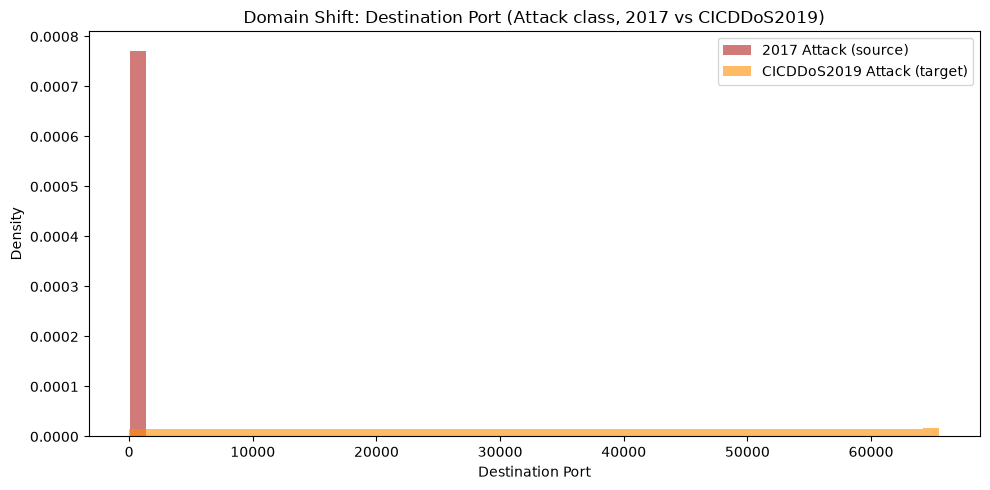

In [7]:
import matplotlib.pyplot as plt
from src.utils import save_figure

top_feature_ddos2019 = shift_attack_ddos2019.iloc[0]["feature"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(X_2017_attack_20[top_feature_ddos2019], bins=50, alpha=0.6, label="2017 Attack (source)", density=True, color="firebrick")
ax.hist(X_ddos2019_attack[top_feature_ddos2019], bins=50, alpha=0.6, label="CICDDoS2019 Attack (target)", density=True, color="darkorange")
ax.set_title(f"Domain Shift: {top_feature_ddos2019} (Attack class, 2017 vs CICDDoS2019)")
ax.set_xlabel(top_feature_ddos2019)
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

save_figure(fig, "domain_shift_cicddos2019_top_feature.png", cfg)
plt.show()